### Phase 1 — Data Cleaning
Notebook initialized on 25–11–2025.

### Step 2 — Extraction & Table Identification


In this step I will:

1. List all raw data sources (PDFs + CSVs).
2. Create an "Extraction Inventory Table" with basic info for each file.
3. Prepare notes for later detailed table mapping.

No actual data extraction happens here – only identification and planning.


In [8]:
import pandas as pd

data_sources = [
    {
        "source_id": "IND_RELOOP_BOOK",
        "folder": "data/raw/industry",
        "filename": "reloop_deposit_book.pdf",
        "format": "pdf",
        "main_use": "Background & possible international deposit stats",
        "status": "To review"
    },
    {
        "source_id": "IND_TOMRA_RATE",
        "folder": "data/raw/industry",
        "filename": "tomra_deposit_rate.pdf",
        "format": "pdf",
        "main_use": "Deposit/return rate comparisons (Germany vs others)",
        "status": "To review"
    },
    {
        "source_id": "IND_TOMRA_WHITEPAPER",
        "folder": "data/raw/industry/tomra_supporting",
        "filename": "TOMRA-Unlocking-Circularity-Whitepaper.pdf",
        "format": "pdf",
        "main_use": "Narrative, context, maybe supporting stats",
        "status": "To review"
    },
    {
        "source_id": "UBA_2022_MAIN",
        "folder": "data/raw/uba",
        "filename": "uba_156_2024.pdf",
        "format": "pdf",
        "main_use": "Official German Pfand data (2022 report)",
        "status": "High priority"
    },
    {
        "source_id": "UBA_2020_MAIN",
        "folder": "data/raw/uba",
        "filename": "uba_109_2022.pdf",
        "format": "pdf",
        "main_use": "Official German Pfand data (2020 report)",
        "status": "High priority"
    },
    {
        "source_id": "UBA_LCA_2024",
        "folder": "data/raw/lca",
        "filename": "uba_124_2024_lca.pdf",
        "format": "pdf",
        "main_use": "CO2 / LCA factors for ESG modeling",
        "status": "To review"
    },
    {
        "source_id": "SUPPORT_CPI",
        "folder": "data/raw/supporting",
        "filename": "CPI_Germany.csv",
        "format": "csv",
        "main_use": "Inflation / CPI trend for context",
        "status": "Ready (no extraction needed)"
    },
    {
        "source_id": "SUPPORT_POP",
        "folder": "data/raw/supporting",
        "filename": "Population_Germany.csv",
        "format": "csv",
        "main_use": "Population trend for per-capita calculations",
        "status": "Ready (no extraction needed)"
    }
]

extraction_inventory = pd.DataFrame(data_sources)
extraction_inventory


,source_id,folder,filename,format,main_use,status
0,IND_RELOOP_BOOK,data/raw/industry,reloop_deposit_book.pdf,pdf,Background & possible international deposit stats,To review
1,IND_TOMRA_RATE,data/raw/industry,tomra_deposit_rate.pdf,pdf,Deposit/return rate comparisons (Germany vs ot...,To review
2,IND_TOMRA_WHITEPAPER,data/raw/industry/tomra_supporting,TOMRA-Unlocking-Circularity-Whitepaper.pdf,pdf,"Narrative, context, maybe supporting stats",To review
3,UBA_2022_MAIN,data/raw/uba,uba_156_2024.pdf,pdf,Official German Pfand data (2022 report),High priority
4,UBA_2020_MAIN,data/raw/uba,uba_109_2022.pdf,pdf,Official German Pfand data (2020 report),High priority
5,UBA_LCA_2024,data/raw/lca,uba_124_2024_lca.pdf,pdf,CO2 / LCA factors for ESG modeling,To review
6,SUPPORT_CPI,data/raw/supporting,CPI_Germany.csv,csv,Inflation / CPI trend for context,Ready (no extraction needed)
7,SUPPORT_POP,data/raw/supporting,Population_Germany.csv,csv,Population trend for per-capita calculations,Ready (no extraction needed)


In [ ]:
extraction_inventory.to_csv("../data/extraction_inventory.csv", index=False)
print("Saved to data/extraction_inventory.csv")


#### Validation Checks (Phase 1 Completion)
This step verifies that all manually extracted tables (90, 99, 100) are internally consistent before entering Phase 2.
We perform four checks:
1. Load extracted datasets
2. Validate input consistency (Table 90 §31 vs Table 99 Verbrauch)
3. Validate recycling rates mathematically using (recycled_kt / input_kt) * 100
4. Check for missing values and
5. Generate quick plots for visual sanity checks
Successful validation confirms that the 2022 Pfand dataset is clean and ready for EDA in Phase 2.

Preview of master table:


,material,pfand_input_kt,total_recycled_kt,recycling_rate_pct
0,Glas,35.4,35.1,99.2
1,Eisenmetalle,26.7,26.6,99.5
2,Aluminium,50.4,50.0,99.2
3,Kunststoff,463.5,441.7,95.3
4,Papier_Pappe_Karton,9.0,NaN,
5,Fluessigkeitskarton,NaN,NaN,NaN



Missing values (before filtering):


material              0
pfand_input_kt        1
total_recycled_kt     2
recycling_rate_pct    2
dtype: int64


Rows kept for validation/plots:


,material,pfand_input_kt,total_recycled_kt,recycling_rate_pct
0,Glas,35.4,35.1,99.2
1,Eisenmetalle,26.7,26.6,99.5
2,Aluminium,50.4,50.0,99.2
3,Kunststoff,463.5,441.7,95.3



Rate consistency check (calc_rate vs recycling_rate_pct):


,material,pfand_input_kt,total_recycled_kt,recycling_rate_pct,calc_rate,rate_diff_pp
2,Aluminium,50.4,50.0,99.2,99.206349,0.006349
1,Eisenmetalle,26.7,26.6,99.5,99.625468,0.125468
0,Glas,35.4,35.1,99.2,99.152542,-0.047458
3,Kunststoff,463.5,441.7,95.3,95.296656,-0.003344



Flags (abs(diff) > 0.5 pp): 0


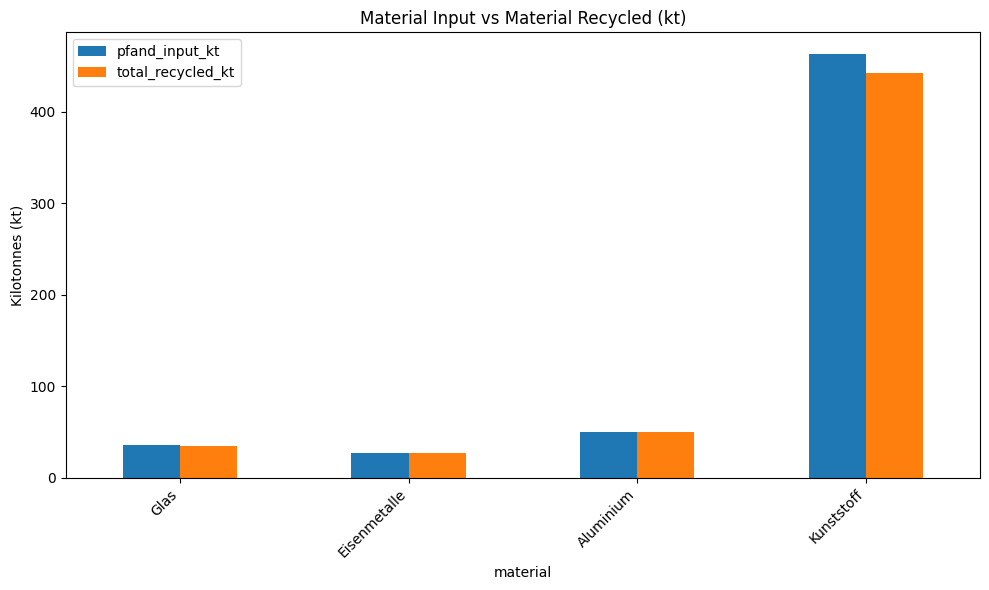

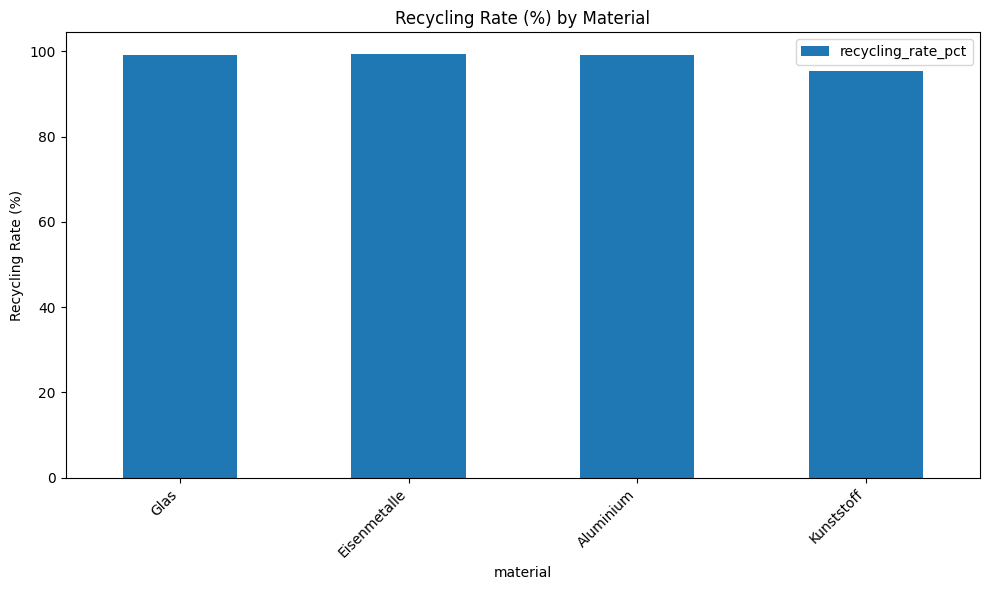

In [1]:
# PHASE 1 — FINAL VALIDATION CHECKS (FIXED + SAFER)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load master dataset
master = pd.read_csv("../data/cleaned/pfand_2022_master.csv")

print("Preview of master table:")
display(master)

# 🔧 Step 1 — Clean numeric columns (robust)
def clean_numeric(series: pd.Series) -> pd.Series:
    """
    Convert messy CSV numeric column to float safely.
    Handles German decimals, blanks, dashes, and other non-numeric tokens.
    """
    s = (
        series.astype(str)
        .str.replace("\u00a0", " ", regex=False)  # non-breaking spaces
        .str.strip()
        .replace({"": np.nan, "None": np.nan, "nan": np.nan, "NaN": np.nan, "-": np.nan, "–": np.nan, "—": np.nan})
        .str.replace(",", ".", regex=False)       # German decimal comma -> dot
    )
    return pd.to_numeric(s, errors="coerce")

num_cols = ["total_recycled_kt", "recycling_rate_pct", "pfand_input_kt"]
for c in num_cols:
    if c not in master.columns:
        raise KeyError(f"Missing expected column: {c}")
    master[c] = clean_numeric(master[c])

# 🟢 Step 2 — Missing values check (BEFORE filtering)
print("\nMissing values (before filtering):")
display(master.isna().sum())

# 🟢 Step 3 — Drop rows that can't be validated/plotted
# (core metrics missing or division by zero)
master_valid = master.dropna(subset=["pfand_input_kt", "total_recycled_kt", "recycling_rate_pct"]).copy()
master_valid = master_valid[master_valid["pfand_input_kt"] > 0]

print("\nRows kept for validation/plots:")
display(master_valid[["material", "pfand_input_kt", "total_recycled_kt", "recycling_rate_pct"]])

# 🟢 Step 4 — Recycling rate math validation
master_valid["calc_rate"] = (master_valid["total_recycled_kt"] / master_valid["pfand_input_kt"]) * 100
master_valid["rate_diff_pp"] = master_valid["calc_rate"] - master_valid["recycling_rate_pct"]

print("\nRate consistency check (calc_rate vs recycling_rate_pct):")
display(master_valid[[
    "material", "pfand_input_kt", "total_recycled_kt",
    "recycling_rate_pct", "calc_rate", "rate_diff_pp"
]].sort_values("material"))

# Optional: flag anything that looks off (tolerance in percentage points)
tolerance_pp = 0.5
flags = master_valid[master_valid["rate_diff_pp"].abs() > tolerance_pp]
print(f"\nFlags (abs(diff) > {tolerance_pp} pp): {len(flags)}")
if len(flags) > 0:
    display(flags[["material", "recycling_rate_pct", "calc_rate", "rate_diff_pp"]])

# 🟢 Step 5 — Visual validations (use the filtered df)
ax = master_valid.plot(
    kind="bar", x="material",
    y=["pfand_input_kt", "total_recycled_kt"],
    figsize=(10,6)
)
plt.title("Material Input vs Material Recycled (kt)")
plt.ylabel("Kilotonnes (kt)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

ax = master_valid.plot(
    kind="bar", x="material",
    y="recycling_rate_pct",
    figsize=(10,6)
)
plt.title("Recycling Rate (%) by Material")
plt.ylabel("Recycling Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
